In [117]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
%matplotlib inline
from IPython.display import Image


Загрузка данных 

In [65]:
df_first = pd.read_excel('ИД.xlsx')

C:\Users\slepnev.py\Anaconda3\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [67]:
df_first.columns.tolist()
df=df_first

In [71]:
df.rename(columns={'эл-т': 'elem'}, inplace=True)

в данных поменяли значения 
AlK, AlK, ALФ2, AlK2 на 1,2,3,4 
С, Ф на 

In [81]:
df['мат'] = np.where((df.мат == 'AlK'), 1, df.мат)
df['мат'] = np.where((df.мат == 'AlK'), 2, df.мат)
df['мат'] = np.where((df.мат == 'ALФ2'), 3, df.мат)
df['мат'] = np.where((df.мат == 'AlK2'), 4, df.мат)
df['elem'] = np.where((df.elem == 'С'), 1, df.elem)
df['elem'] = np.where((df.elem == 'Ф'), 2, df.elem)
df = df.fillna(0)

In [83]:
df.columns.tolist()

['мат',
 'н-р',
 'elem',
 'усл',
 'особ',
 'травлен',
 'U',
 't,мин',
 'T',
 'dпор, нм',
 'название',
 'Unnamed: 11']

In [87]:
cols = ['мат',
 'н-р',
 'elem',
 'U',
 't,мин',
 'T']
a = df[cols]

Диаграмма корреляции признаков. Черные значения - коррелирует наоборот, светлые - корреляция в том же направлении. Сами с собой корреляция равна единице

<AxesSubplot:>

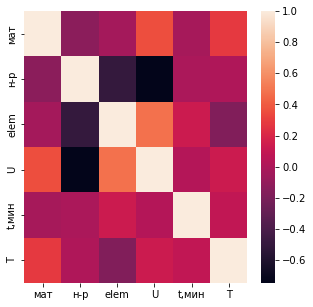

In [91]:
plt.figure(figsize = (5,5))
sns.heatmap(a.corr())

Значения корреляции в числовом виде. Более-менее норм, если от 0,5

In [92]:
print(a.corr())

            мат       н-р      elem         U     t,мин         T
мат    1.000000 -0.137594 -0.035911  0.352523 -0.028260  0.280287
н-р   -0.137594  1.000000 -0.504944 -0.745745 -0.006194  0.010877
elem  -0.035911 -0.504944  1.000000  0.480106  0.131386 -0.176840
U      0.352523 -0.745745  0.480106  1.000000  0.029741  0.127432
t,мин -0.028260 -0.006194  0.131386  0.029741  1.000000  0.082332
T      0.280287  0.010877 -0.176840  0.127432  0.082332  1.000000


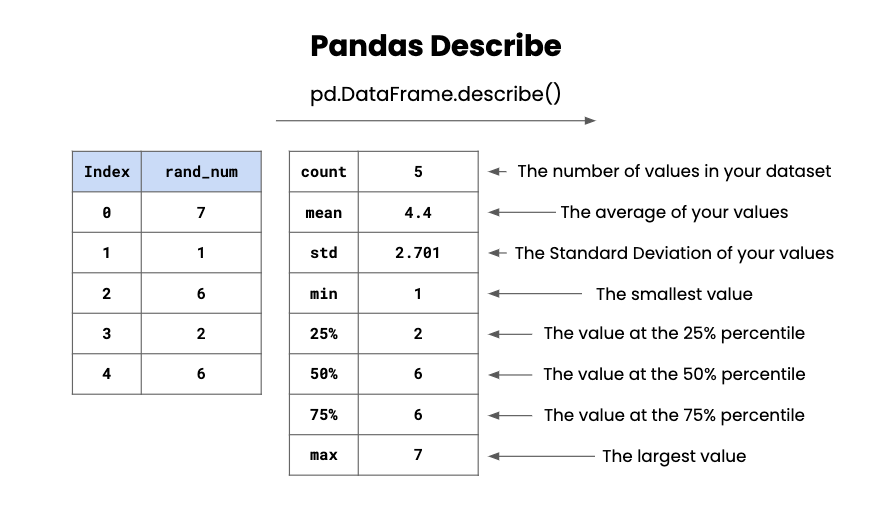

In [124]:
Image("img.png",width = 500)

In [99]:
df.describe()

,мат,н-р,elem,U,"t,мин",T
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,1.645833,5.645833,1.770833,75.354167,44.708333,16.041667
std,0.956269,7.280079,0.555038,28.655689,75.943416,8.788189
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,2.000000,80.000000,8.000000,10.000000
50%,1.000000,3.000000,2.000000,80.000000,20.000000,15.000000
75%,2.000000,5.000000,2.000000,90.750000,50.000000,18.000000
max,4.000000,26.000000,2.000000,120.000000,455.000000,40.000000


Гистограммы накопленных значений

array([[<AxesSubplot:title={'center':'мат'}>,
        <AxesSubplot:title={'center':'н-р'}>],
       [<AxesSubplot:title={'center':'elem'}>,
        <AxesSubplot:title={'center':'U'}>],
       [<AxesSubplot:title={'center':'t,мин'}>,
        <AxesSubplot:title={'center':'T'}>]], dtype=object)

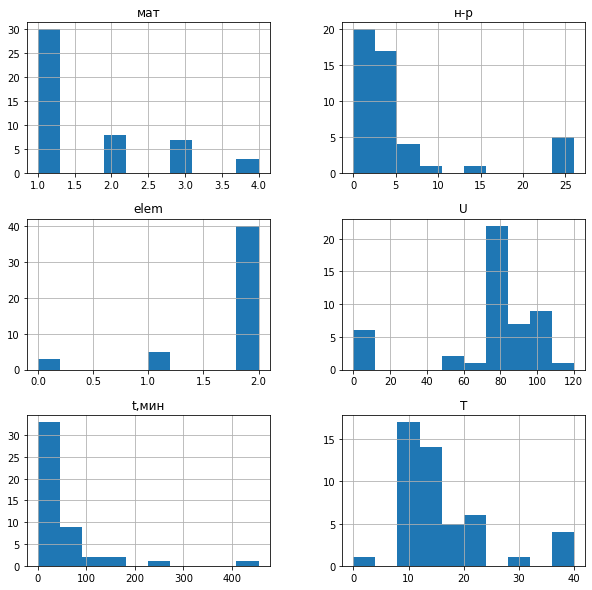

In [100]:
a.hist(a.columns, figsize=(10,10))